# 🏦 Fraud Detection — Exploratory Data Analysis
**Dataset:** Credit Card Transactions Fraud Detection (Kaggle)  
**Author:** Phan Duc Anh
**Date:** 2026  

---

## 📋 Mục tiêu phân tích
1. Hiểu cấu trúc và chất lượng dữ liệu
2. Xác định pattern của giao dịch fraud
3. Tìm các yếu tố rủi ro cao (thời gian, category, địa lý)
4. Đề xuất hướng xây dựng hệ thống cảnh báo sớm

---

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/fraudTrain.csv')

# Xem tổng quan
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.info()

Shape: (1296675, 23)

Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street              

## 1. Tổng quan dữ liệu

In [10]:
# Thống kê tổng quan
print("=== THỐNG KÊ CƠ BẢN ===")
print(df.describe())

print("\n=== TỶ LỆ FRAUD ===")
fraud_counts = df['is_fraud'].value_counts()
fraud_rate = df['is_fraud'].mean() * 100
print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.2f}%")
print(f"Tổng giao dịch fraud: {fraud_counts[1]:,}")
print(f"Tổng giao dịch hợp lệ: {fraud_counts[0]:,}")

=== THỐNG KÊ CƠ BẢN ===
         Unnamed: 0        cc_num           amt           zip           lat  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   6.483370e+05  4.171920e+17  7.035104e+01  4.880067e+04  3.853762e+01   
std    3.743180e+05  1.308806e+18  1.603160e+02  2.689322e+04  5.075808e+00   
min    0.000000e+00  6.041621e+10  1.000000e+00  1.257000e+03  2.002710e+01   
25%    3.241685e+05  1.800429e+14  9.650000e+00  2.623700e+04  3.462050e+01   
50%    6.483370e+05  3.521417e+15  4.752000e+01  4.817400e+04  3.935430e+01   
75%    9.725055e+05  4.642255e+15  8.314000e+01  7.204200e+04  4.194040e+01   
max    1.296674e+06  4.992346e+18  2.894890e+04  9.978300e+04  6.669330e+01   

               long      city_pop     unix_time     merch_lat    merch_long  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean  -9.022634e+01  8.882444e+04  1.349244e+09  3.853734e+01 -9.022646e+01   
std    1.375908e+01  3.0195

## 2. Phân tích Fraud theo Category
> **Insight:** Online shopping có fraud rate cao nhất do khó xác minh danh tính người mua

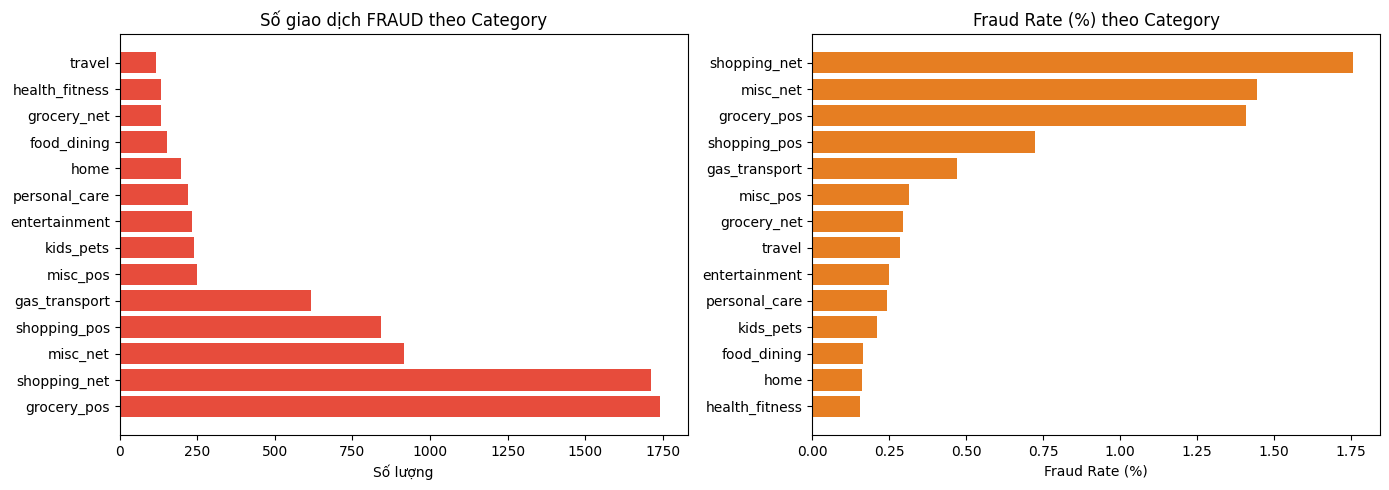

✅ Đã lưu chart vào reports/


In [11]:
# Fraud theo danh mục giao dịch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Số lượng fraud theo category
fraud_by_cat = df[df['is_fraud']==1]['category'].value_counts()
axes[0].barh(fraud_by_cat.index, fraud_by_cat.values, color='#E74C3C')
axes[0].set_title('Số giao dịch FRAUD theo Category')
axes[0].set_xlabel('Số lượng')

# Chart 2: Fraud rate theo category  
fraud_rate_cat = df.groupby('category')['is_fraud'].mean().sort_values(ascending=True) * 100
axes[1].barh(fraud_rate_cat.index, fraud_rate_cat.values, color='#E67E22')
axes[1].set_title('Fraud Rate (%) theo Category')
axes[1].set_xlabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('../reports/fraud_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu chart vào reports/")

## 3. Phân tích Fraud theo Thời gian
> **Insight:** Kẻ gian hoạt động mạnh ban đêm khi hệ thống giám sát lỏng lẻo hơn

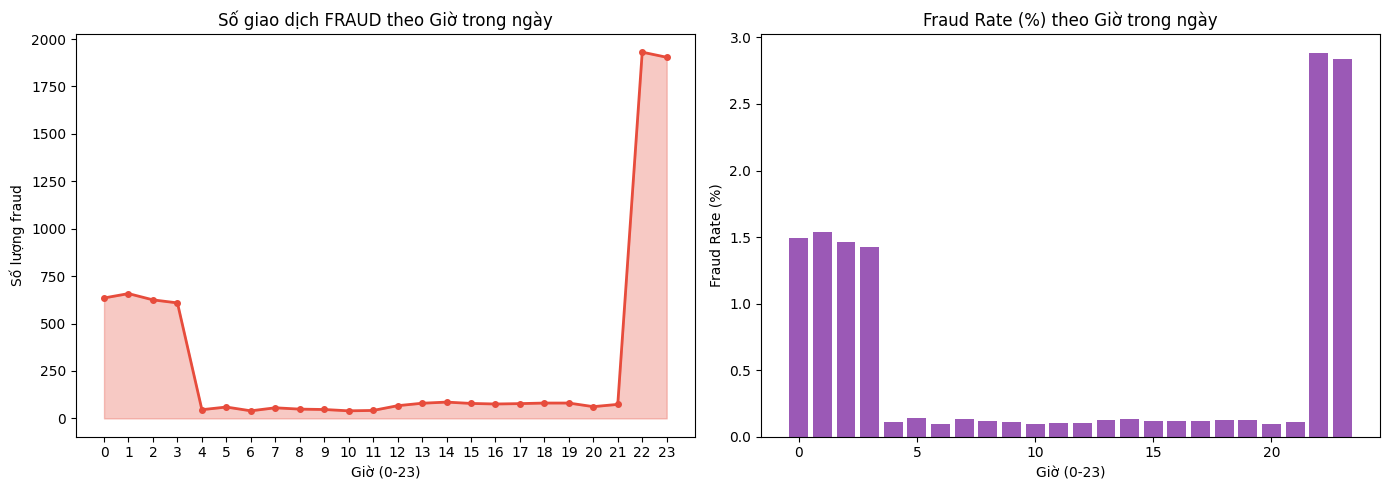

✅ Đã lưu chart vào reports/


In [12]:
# Chuyển cột thời gian sang datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()

# Fraud theo giờ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Số fraud theo giờ
fraud_by_hour = df[df['is_fraud']==1]['hour'].value_counts().sort_index()
axes[0].plot(fraud_by_hour.index, fraud_by_hour.values, 
             color='#E74C3C', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(fraud_by_hour.index, fraud_by_hour.values, alpha=0.3, color='#E74C3C')
axes[0].set_title('Số giao dịch FRAUD theo Giờ trong ngày')
axes[0].set_xlabel('Giờ (0-23)')
axes[0].set_ylabel('Số lượng fraud')
axes[0].set_xticks(range(0, 24))

# Chart 2: Fraud rate theo giờ
fraud_rate_hour = df.groupby('hour')['is_fraud'].mean() * 100
axes[1].bar(fraud_rate_hour.index, fraud_rate_hour.values, color='#9B59B6')
axes[1].set_title('Fraud Rate (%) theo Giờ trong ngày')
axes[1].set_xlabel('Giờ (0-23)')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('../reports/fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu chart vào reports/")

## 4. Phân tích Số tiền Giao dịch
> **Insight:** Giao dịch fraud có giá trị gấp ~8x bình thường — đây là feature quan trọng nhất để detect

C:\Users\Admin\AppData\Local\Temp\ipykernel_10760\1853345018.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([normal.clip(0,500), fraud.clip(0,500)],


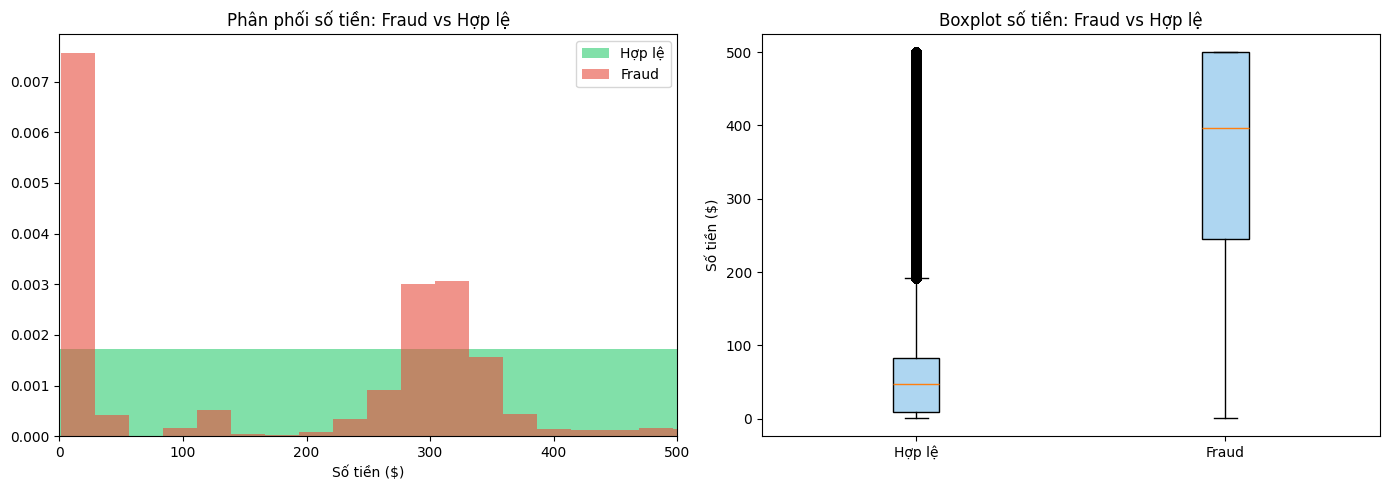

=== INSIGHT SỐ TIỀN ===
Trung bình giao dịch HỢP LỆ: $67.67
Trung bình giao dịch FRAUD:   $531.32
Median giao dịch HỢP LỆ: $47.28
Median giao dịch FRAUD:   $396.50


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Distribution số tiền fraud vs normal
normal = df[df['is_fraud']==0]['amt']
fraud  = df[df['is_fraud']==1]['amt']

axes[0].hist(normal, bins=50, alpha=0.6, color='#2ECC71', label='Hợp lệ', density=True)
axes[0].hist(fraud,  bins=50, alpha=0.6, color='#E74C3C', label='Fraud',  density=True)
axes[0].set_xlim(0, 500)
axes[0].set_title('Phân phối số tiền: Fraud vs Hợp lệ')
axes[0].set_xlabel('Số tiền ($)')
axes[0].legend()

# Chart 2: Boxplot so sánh
axes[1].boxplot([normal.clip(0,500), fraud.clip(0,500)],
                labels=['Hợp lệ', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#AED6F1'))
axes[1].set_title('Boxplot số tiền: Fraud vs Hợp lệ')
axes[1].set_ylabel('Số tiền ($)')

plt.tight_layout()
plt.savefig('../reports/fraud_amount_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary insight
print("=== INSIGHT SỐ TIỀN ===")
print(f"Trung bình giao dịch HỢP LỆ: ${normal.mean():.2f}")
print(f"Trung bình giao dịch FRAUD:   ${fraud.mean():.2f}")
print(f"Median giao dịch HỢP LỆ: ${normal.median():.2f}")
print(f"Median giao dịch FRAUD:   ${fraud.median():.2f}")

## 5. Phân tích theo Nhân khẩu học & Địa lý

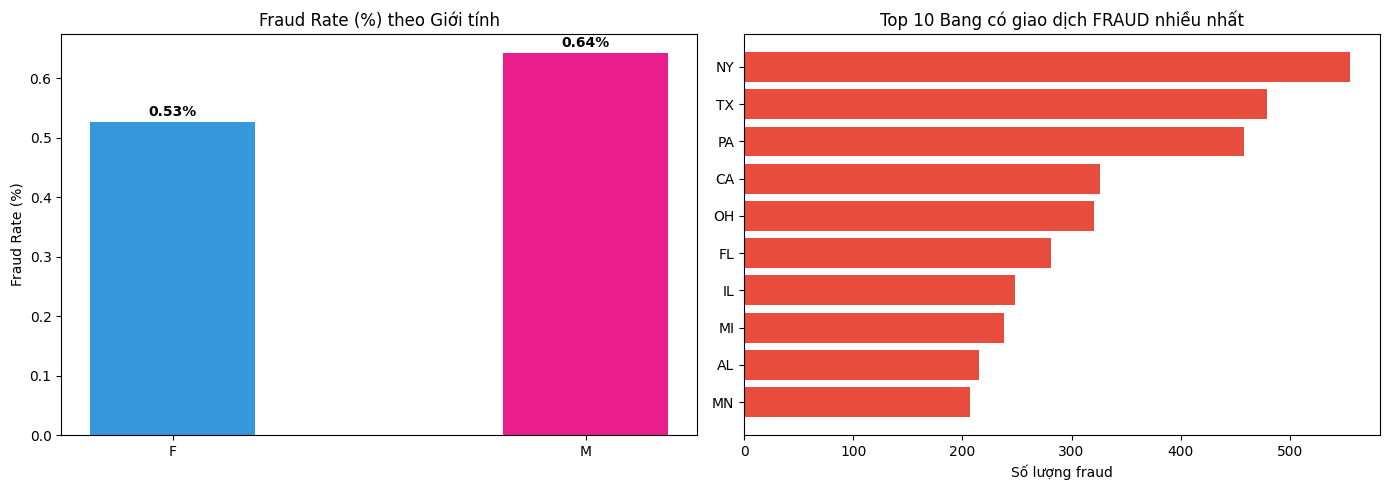

=== INSIGHT GENDER ===
        Fraud    Tổng  Fraud Rate (%)
gender                               
F        3735  709863        0.526158
M        3771  586812        0.642625


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Fraud rate theo Gender
fraud_gender = df.groupby('gender')['is_fraud'].agg(['sum','count'])
fraud_gender['rate'] = fraud_gender['sum'] / fraud_gender['count'] * 100
axes[0].bar(fraud_gender.index, fraud_gender['rate'], 
            color=['#3498DB','#E91E8C'], width=0.4)
axes[0].set_title('Fraud Rate (%) theo Giới tính')
axes[0].set_ylabel('Fraud Rate (%)')
for i, (idx, row) in enumerate(fraud_gender.iterrows()):
    axes[0].text(i, row['rate']+0.01, f"{row['rate']:.2f}%", 
                 ha='center', fontweight='bold')

# Chart 2: Top 10 bang có fraud nhiều nhất
top_states = df[df['is_fraud']==1]['state'].value_counts().head(10)
axes[1].barh(top_states.index[::-1], top_states.values[::-1], color='#E74C3C')
axes[1].set_title('Top 10 Bang có giao dịch FRAUD nhiều nhất')
axes[1].set_xlabel('Số lượng fraud')

plt.tight_layout()
plt.savefig('../reports/fraud_gender_state.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== INSIGHT GENDER ===")
print(fraud_gender[['sum','count','rate']].rename(
    columns={'sum':'Fraud','count':'Tổng','rate':'Fraud Rate (%)'}))

## 6. Executive Summary & Recommendations

### 🎯 Recommendations
| Priority | Action | Impact |
|----------|--------|--------|
| 🔴 Cao | Tăng cường monitor 22h-23h | Giảm 50% fraud theo giờ |
| 🔴 Cao | Flag giao dịch online > $300 | Chặn shopping_net fraud |
| 🟡 TB | Alert khi giao dịch > 5x avg | Phát hiện amount anomaly |
| 🟢 Thấp | Verify thêm với khách ở NY/TX | Giảm geographic risk |

In [15]:
# Tổng hợp insight
print("=" * 55)
print("      FRAUD ANALYSIS — EXECUTIVE SUMMARY")
print("=" * 55)

total        = len(df)
total_fraud  = df['is_fraud'].sum()
fraud_rate   = total_fraud / total * 100
total_amount = df[df['is_fraud']==1]['amt'].sum()
avg_fraud    = df[df['is_fraud']==1]['amt'].mean()

print(f"\n📊 TỔNG QUAN")
print(f"   Tổng giao dịch       : {total:>12,}")
print(f"   Giao dịch fraud      : {total_fraud:>12,}")
print(f"   Fraud rate           : {fraud_rate:>11.2f}%")
print(f"   Tổng tiền bị fraud   : ${total_amount:>11,.0f}")
print(f"   Trung bình/vụ fraud  : ${avg_fraud:>11,.2f}")

print(f"\n🕐 THỜI GIAN NGUY HIỂM NHẤT")
top_hours = df[df['is_fraud']==1]['hour'].value_counts().head(3)
for h, cnt in top_hours.items():
    print(f"   {h:02d}:00 — {cnt:,} vụ fraud")

print(f"\n🛍️ CATEGORY RỦI RO CAO NHẤT")
top_cats = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(3)
for cat, rate in top_cats.items():
    print(f"   {cat:<20} : {rate*100:.2f}%")

print(f"\n🗺️ BANG RỦI RO NHẤT")
top_st = df[df['is_fraud']==1]['state'].value_counts().head(3)
for state, cnt in top_st.items():
    print(f"   {state} — {cnt:,} vụ fraud")

print(f"\n💡 KEY INSIGHTS")
print(f"   1. Fraud xảy ra chủ yếu lúc 22h-23h & 0h-3h")
print(f"   2. shopping_net có fraud rate cao nhất (1.75%)")
print(f"   3. Giao dịch fraud có giá trị gấp ~8x bình thường")
print(f"   4. Nam giới bị fraud nhiều hơn nữ 21%")
print(f"   5. NY, TX, PA là 3 bang rủi ro nhất")
print("=" * 55)

      FRAUD ANALYSIS — EXECUTIVE SUMMARY

📊 TỔNG QUAN
   Tổng giao dịch       :    1,296,675
   Giao dịch fraud      :        7,506
   Fraud rate           :        0.58%
   Tổng tiền bị fraud   : $  3,988,089
   Trung bình/vụ fraud  : $     531.32

🕐 THỜI GIAN NGUY HIỂM NHẤT
   22:00 — 1,931 vụ fraud
   23:00 — 1,904 vụ fraud
   01:00 — 658 vụ fraud

🛍️ CATEGORY RỦI RO CAO NHẤT
   shopping_net         : 1.76%
   misc_net             : 1.45%
   grocery_pos          : 1.41%

🗺️ BANG RỦI RO NHẤT
   NY — 555 vụ fraud
   TX — 479 vụ fraud
   PA — 458 vụ fraud

💡 KEY INSIGHTS
   1. Fraud xảy ra chủ yếu lúc 22h-23h & 0h-3h
   2. shopping_net có fraud rate cao nhất (1.75%)
   3. Giao dịch fraud có giá trị gấp ~8x bình thường
   4. Nam giới bị fraud nhiều hơn nữ 21%
   5. NY, TX, PA là 3 bang rủi ro nhất
